### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.utils.validation import check_is_fitted

np.random.seed(42) # In order to have the same result as corrector

MU0 = np.array([0.0, 0.0])
SIGMA0 = np.array([[0.5, 0.0], [0.0, 0.5]])
SIGMA1 = np.array([[0.4, 0.0], [0.0, 0.4]])

def gen_dataset(N, eps, p, seed=None):
    rng = np.random.default_rng(seed)
    mu1 = np.array([eps, 0.0])
    
    # Sample labels
    y = (rng.uniform(size=N) < p).astype(int)
    
    # Sample features
    X = np.where(
        y[:, None] == 0,
        rng.multivariate_normal(MU0, SIGMA0, size=N),
        rng.multivariate_normal(mu1, SIGMA1, size=N)
    )
    return X, y

# Datasets
X_train, y_train = gen_dataset(50,   eps=2, p=0.30, seed=0)
X_test,  y_test  = gen_dataset(1000, eps=2, p=0.30, seed=1)



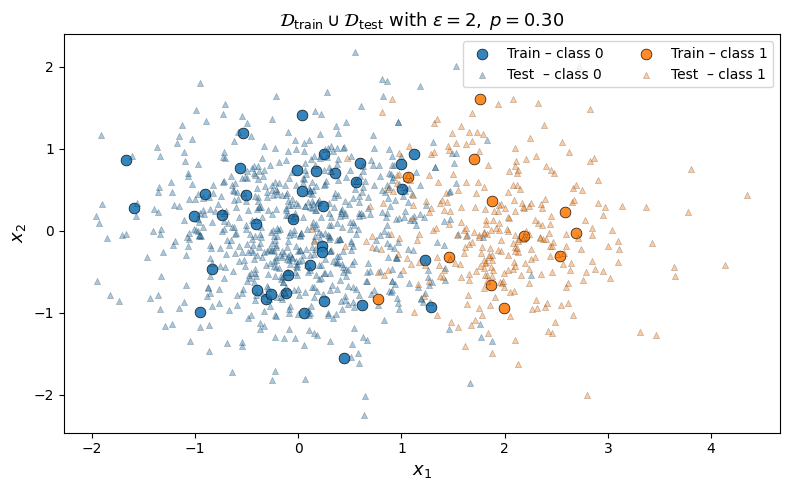

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))

# colour palette: blue = class 0, orange = class 1
colors = {0: '#1f77b4', 1: '#ff7f0e'}

for cls in [0, 1]:
    # Training points  (circles)
    mask_tr = y_train == cls
    ax.scatter(X_train[mask_tr, 0], X_train[mask_tr, 1],
               marker='o', color=colors[cls], edgecolors='k', linewidths=0.5,
               s=60, label=f'Train – class {cls}', alpha=0.9)
    # Test points  (triangles)
    mask_te = y_test == cls
    ax.scatter(X_test[mask_te, 0], X_test[mask_te, 1],
               marker='^', color=colors[cls], edgecolors='k', linewidths=0.3,
               s=20, label=f'Test  – class {cls}', alpha=0.4)

ax.set_xlabel(r'$x_1$', fontsize=13)
ax.set_ylabel(r'$x_2$', fontsize=13)
ax.set_title(r'$\mathcal{D}_{\rm train} \cup \mathcal{D}_{\rm test}$ with $\varepsilon=2,\; p=0.30$',
             fontsize=13)
ax.legend(fontsize=10, ncol=2)
plt.tight_layout()
plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

**Bayes classifier.** The Bayes-optimal rule predicts

$$
\hat{g}(\mathbf{x}) = \operatorname*{arg\,max}_{k\in\{0,1\}} \underbrace{P(Y=k)}_{\text{prior}} \cdot \underbrace{p(\mathbf{x}\mid Y=k)}_{\text{likelihood}}
$$

which is equivalent to predicting class 1 if the **log-posterior ratio** is positive:

$$
\Lambda(\mathbf{x}) \;:=\; \log\frac{P(Y=1\mid\mathbf{x})}{P(Y=0\mid\mathbf{x})}
= \log\frac{p}{1-p}
+ \log\frac{\mathcal{N}(\mathbf{x};\boldsymbol{\mu}_1,\boldsymbol{\Sigma}_1)}
           {\mathcal{N}(\mathbf{x};\boldsymbol{\mu}_0,\boldsymbol{\Sigma}_0)} \;>\; 0
$$

Expanding the Gaussian log-ratio (both covariances are diagonal with $\sigma_0^2=0.5$, $\sigma_1^2=0.4$):

$$
\Lambda(\mathbf{x}) = \log\frac{p}{1-p} + \log\frac{\sigma_0}{\sigma_1}
- \frac{\|\mathbf{x}-\boldsymbol{\mu}_1\|^2}{2\sigma_1^2}
+ \frac{\|\mathbf{x}-\boldsymbol{\mu}_0\|^2}{2\sigma_0^2}
$$

**Decision boundary** $\{\mathbf{x}:\Lambda(\mathbf{x})=0\}$. Substituting the numerical values and expanding gives:

$$
\log\frac{p}{1-p} + \log\frac{5}{4}
-\frac{5}{4}\left[(x_1-\varepsilon)^2+x_2^2\right]
+\left[x_1^2+x_2^2\right] = 0
$$

Re-arranging yields a **circle** in $\mathbb{R}^2$:

$$
\left(x_1 - 5\varepsilon\right)^2 + x_2^2
= 20\varepsilon^2 + 4\log\frac{p}{1-p} + 4\log\frac{5}{4}
$$

centred at $(5\varepsilon, 0)$ with radius $r = \sqrt{20\varepsilon^2 + 4\log\tfrac{p}{1-p} + 4\log\tfrac{5}{4}}$.

For $\varepsilon=2,\,p=0.30$ the centre is at $(10, 0)$, far from the data, so the boundary looks nearly linear in the region of interest, as visualised below.

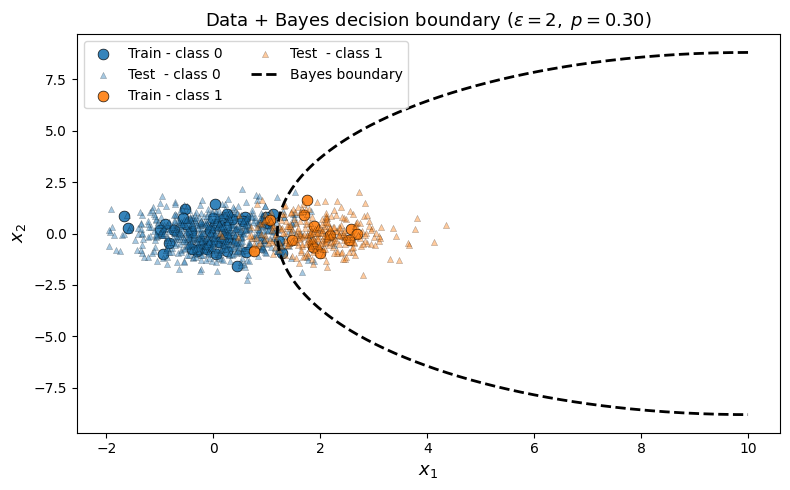

In [25]:
eps, p = 2.0, 0.30

# Circle parameters from the boundary equation derived in (b):
#   (x1 - 5*eps)^2 + x2^2 = 20*eps^2 + 4*log(p/(1-p)) + 4*log(5/4)
cx = 5 * eps
cy = 0.0
r  = np.sqrt(20 * eps**2 + 4 * np.log(p / (1 - p)) + 4 * np.log(5 / 4))

# Only the left arc is visible in the data region (centre is at x1=10, far right)
theta = np.linspace(np.pi / 2, 3 * np.pi / 2, 500)
x1_bd = cx + r * np.cos(theta)
x2_bd = cy + r * np.sin(theta)

colors = {0: '#1f77b4', 1: '#ff7f0e'}
fig, ax = plt.subplots(figsize=(8, 5))
for cls in [0, 1]:
    mask_tr = y_train == cls
    ax.scatter(X_train[mask_tr, 0], X_train[mask_tr, 1],
               marker='o', color=colors[cls], edgecolors='k', linewidths=0.5,
               s=60, label=f'Train - class {cls}', alpha=0.9)
    mask_te = y_test == cls
    ax.scatter(X_test[mask_te, 0], X_test[mask_te, 1],
               marker='^', color=colors[cls], edgecolors='k', linewidths=0.3,
               s=20, label=f'Test  - class {cls}', alpha=0.4)
ax.plot(x1_bd, x2_bd, 'k--', linewidth=2, label='Bayes boundary')
ax.set_xlabel(r'$x_1$', fontsize=13)
ax.set_ylabel(r'$x_2$', fontsize=13)
ax.set_title(r'Data + Bayes decision boundary ($\varepsilon=2,\; p=0.30$)', fontsize=13)
ax.legend(fontsize=10, ncol=2)
plt.tight_layout()
plt.show()


**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

Bayes error (eps=2, p=0.30, N=500000): 0.0617


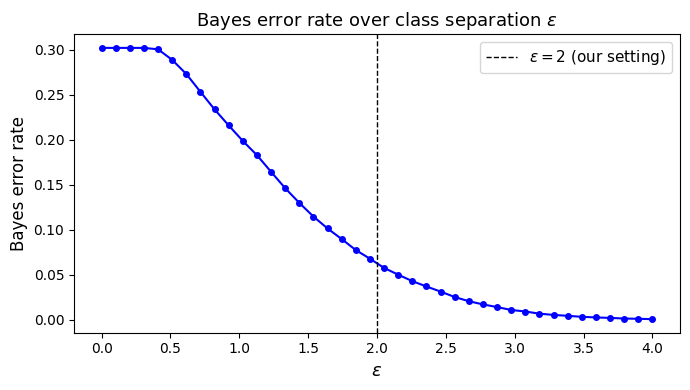

In [3]:
class BayesClassifier(BaseEstimator, ClassifierMixin):
    
    def __init__(self, mu0, mu1, sigma0, sigma1, p):
        self.mu0 = mu0
        self.mu1 = mu1
        self.sigma0 = sigma0
        self.sigma1 = sigma1
        self.p = p
        
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        return self
    
    def _log_posterior_ratio(self, X):
        log_ratio_prior = np.log(self.p / (1 - self.p))
        log_lik1 = multivariate_normal.logpdf(X, mean=self.mu1, cov=self.sigma1)
        log_lik0 = multivariate_normal.logpdf(X, mean=self.mu0, cov=self.sigma0)
        return log_ratio_prior + log_lik1 - log_lik0
    
    def predict(self, X):
        check_is_fitted(self)
        return (self._log_posterior_ratio(X) > 0).astype(int)
    
    def predict_proba(self, X):
        check_is_fitted(self)
        ratio = np.exp(self._log_posterior_ratio(X))
        p1 = ratio / (1 + ratio)
        return np.column_stack([1 - p1, p1])
    
eps_ref, p_ref = 2.0, 0.30
X_large, y_large = gen_dataset(500_000, eps=eps_ref, p=p_ref, seed=99)

bayes_clf = BayesClassifier(
    mu0=MU0, mu1=np.array([eps_ref, 0.0]),
    sigma0=SIGMA0, sigma1=SIGMA1, p=p_ref
)
bayes_clf.fit(X_large, y_large)         # fit is a no-op but needed by sklearn
bayes_error = 1 - accuracy_score(y_large, bayes_clf.predict(X_large))
print(f"Bayes error (eps=2, p=0.30, N=500000): {bayes_error:.4f}")

eps_values  = np.linspace(0.0, 4.0, 40)
bayes_errors = []

for eps in eps_values:
    X_e, y_e = gen_dataset(10_000, eps=eps, p=p_ref, seed=7)
    clf = BayesClassifier(
        mu0=MU0, mu1=np.array([eps, 0.0]),
        sigma0=SIGMA0, sigma1=SIGMA1, p=p_ref
    )
    clf.fit(X_e, y_e)
    bayes_errors.append(1 - accuracy_score(y_e, clf.predict(X_e)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(eps_values, bayes_errors, 'b-o', markersize=4, linewidth=1.5)
ax.axvline(x=2.0, color='k', linestyle='--', linewidth=1, label=r'$\varepsilon=2$ (our setting)')
ax.set_xlabel(r'$\varepsilon$', fontsize=13)
ax.set_ylabel('Bayes error rate', fontsize=12)
ax.set_title('Bayes error rate over class separation $\\varepsilon$', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

As $\varepsilon$ increases, the two class means move further apart, making the classes easier to separate and the Bayes error monotonically decreases towards 0. When $\varepsilon = 0$ both classes overlap maximally and the error approaches $\min(p, 1-p) = 0.30$ (always predicting the majority class).

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

The data are generated from two **Gaussian** classes with **different covariance matrices** ($\boldsymbol{\Sigma}_0 \neq \boldsymbol{\Sigma}_1$). Here is how each classifier fares against this structure:

| Classifier | Key assumptions | Suitability here |
|---|---|---|
| **kNN** | None (non-parametric) | Works, but slow to converge; sensitive to $k$ and scale |
| **Logistic regression** | Linear decision boundary | Poor fit : boundary is a circle (quadratic) |
| **LDA** | Gaussian classes, **equal** covariances | Misspecified: assumes $\boldsymbol{\Sigma}_0=\boldsymbol{\Sigma}_1$, gives a linear boundary |
| **QDA** | Gaussian classes, **arbitrary** covariances | the true boundary is exactly what QDA estimates |
| **Naïve Bayes** | Gaussian classes + feature **independence** | Features are already independent here (diagonal $\boldsymbol{\Sigma}$), so NB is also a good fit, though it still assumes equal variances across classes unless `var_smoothing` is tuned |
| **Random Forest** | None (non-parametric, tree-based) | Can approximate any boundary but needs more data and is less sample-efficient |
| **Gradient Boosted Trees** | None (non-parametric, tree-based) | Same as RF : powerful but over-parametrised for this simple problem |

**QDA** is the most adequate: its generative model matches the true distribution exactly, so given enough data it recovers the Bayes-optimal (circular) decision boundary with the minimum number of parameters.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

Classifier               Test error     Gap to Bayes
----------------------------------------------------
LDA                          0.0730          +0.0113
QDA                          0.0720          +0.0103
Logistic Regression          0.0750          +0.0133
Bayes (oracle)               0.0617              ---


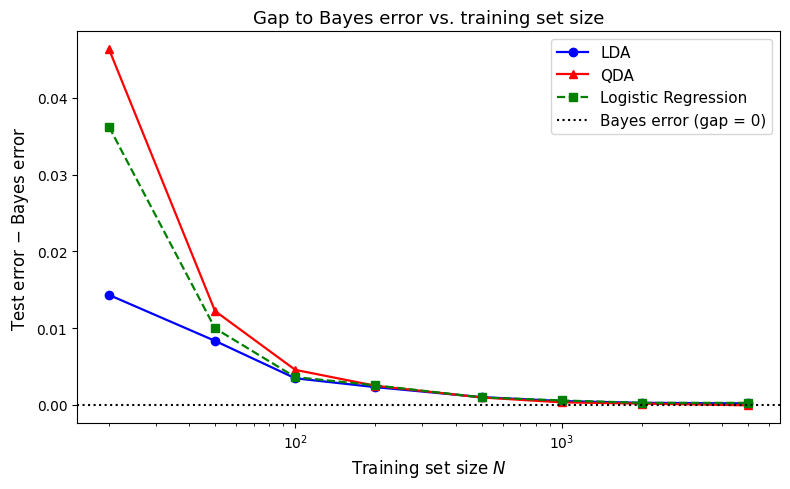

In [4]:
classifiers = {
    'LDA'                : LinearDiscriminantAnalysis(),
    'QDA'                : QuadraticDiscriminantAnalysis(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
}

print(f"{'Classifier':<22} {'Test error':>12}   {'Gap to Bayes':>14}")
print('-' * 52)
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    err = 1 - accuracy_score(y_test, clf.predict(X_test))
    print(f"{name:<22} {err:>12.4f}   {err - bayes_error:>+14.4f}")
print(f"{'Bayes (oracle)':<22} {bayes_error:>12.4f}   {'---':>14}")

train_sizes = [20, 50, 100, 200, 500, 1000, 2000, 5000]
n_repeats   = 30
results     = {name: [] for name in classifiers}

def clone_clf(clf):
    return clf.__class__(**clf.get_params())

for N in train_sizes:
    tmp = {name: [] for name in classifiers}
    for rep in range(n_repeats):
        X_tr, y_tr = gen_dataset(N,    eps=2, p=0.30, seed=rep * 100 + N)
        X_te, y_te = gen_dataset(3000, eps=2, p=0.30, seed=rep + 50000)
        if np.bincount(y_tr, minlength=2).min() < 2:
            continue
        for name, clf in classifiers.items():
            try:
                clf_new = clone_clf(clf)
                clf_new.fit(X_tr, y_tr)
                err = 1 - accuracy_score(y_te, clf_new.predict(X_te))
                tmp[name].append(err - bayes_error)
            except ValueError:
                pass
    for name in classifiers:
        results[name].append(np.mean(tmp[name]) if tmp[name] else np.nan)

styles = {
    'LDA'                : ('blue',  'o', '-'),
    'QDA'                : ('red',   '^', '-'),
    'Logistic Regression': ('green', 's', '--'),
}
fig, ax = plt.subplots(figsize=(8, 5))
for name, (color, marker, ls) in styles.items():
    ax.plot(train_sizes, results[name], ls, color=color,
            marker=marker, markersize=6, linewidth=1.6, label=name)
ax.axhline(y=0, color='k', linestyle=':', linewidth=1.5, label='Bayes error (gap = 0)')
ax.set_xscale('log')
ax.set_xlabel('Training set size $N$', fontsize=12)
ax.set_ylabel('Test error $-$ Bayes error', fontsize=12)
ax.set_title('Gap to Bayes error vs. training set size', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


**Error comparison with the Bayes error (c):**

All three classifiers have a higher test error than the Bayes error, but for fundamentally different reasons, which also determines whether the gap can close as $N$ grows.

---

**Theoretical analysis** via the bias-variance decomposition of excess risk:

$$R(\hat{f}) - R^* = \underbrace{\big[R(f^*_{\mathcal{F}}) - R^*\big]}_{\text{approximation error (bias}^2\text{)}} + \underbrace{\big[R(\hat{f}) - R(f^*_{\mathcal{F}})\big]}_{\text{estimation error (variance)}}$$

where $R^*$ is the Bayes error, $\mathcal{F}$ is the hypothesis class of the classifier, and $f^*_{\mathcal{F}}$ is the best possible classifier within $\mathcal{F}$.

- **QDA**: The true decision boundary is quadratic (a circle, as derived in (b)), and QDA's hypothesis class contains all quadratic boundaries. Therefore the **approximation error is zero**. The only gap comes from the estimation error, which vanishes as $N \to \infty$ since QDA is a consistent estimator of the Gaussian parameters. The gap therefore **decreases to 0**.

- **LDA**: LDA constrains the boundary to be linear ($\mathcal{F}$ = all linear classifiers). Since the true boundary is a circle, a line can never represent it exactly, so the **approximation error is strictly positive and irreducible**. The estimation error still vanishes with $N$, but the gap converges to a **positive constant** determined by how poorly the best linear boundary approximates the true circular one.

- **Logistic regression**: Logistic regression also produces a linear decision boundary (it models $\log[p/(1-p)]$ as a linear function of $\mathbf{x}$). It therefore shares the same irreducible approximation error as LDA, and its gap also **plateaus at a positive constant** as $N$ grows. In practice it often behaves similarly to LDA on Gaussian data because both are fitting a linear boundary to the same problem.

---

**Empirical observation:**

The learning curve above plots the gap (test error $-$ Bayes error) as a function of $N$. It confirms the theory:
- The **QDA** gap steadily decreases towards 0.
- The **LDA** and **logistic regression** gaps decrease initially (as estimation error falls) but then flatten out at a non-zero residual, no matter how much data is added.

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [5]:
X_test2, y_test2 = gen_dataset(1000, eps=0.5, p=0.70, seed=42)

print(f"{'Classifier':<22} {'Error on D_test':>16} {'Error on D\'_test':>17}")
print('-' * 57)
for name, clf in classifiers.items():
    err1 = 1 - accuracy_score(y_test,  clf.predict(X_test))
    err2 = 1 - accuracy_score(y_test2, clf.predict(X_test2))
    print(f"{name:<22} {err1:>16.4f} {err2:>17.4f}")

# Bayes oracle for D'_test
bayes2 = BayesClassifier(
    mu0=MU0, mu1=np.array([0.5, 0.0]),
    sigma0=SIGMA0, sigma1=SIGMA1, p=0.70
)
bayes2.fit(X_test2, y_test2)
err_bayes2 = 1 - accuracy_score(y_test2, bayes2.predict(X_test2))
print(f"{'Bayes oracle D\'_test':<22} {'':>16} {err_bayes2:>17.4f}")


Classifier              Error on D_test  Error on D'_test
---------------------------------------------------------
LDA                              0.0730            0.6290
QDA                              0.0720            0.6270
Logistic Regression              0.0750            0.6480
Bayes oracle D'_test                               0.2680


**Observation:** All three classifiers show a noticeably higher error on $\mathcal{D}'_\text{test}$ compared to $\mathcal{D}_\text{test}$, even though they were not retrained. Two distinct shifts explain this:

**1. Prior shift** ($p: 0.30 \to 0.70$). Every classifier absorbed the training prior — they were calibrated assuming class 1 is the minority. On $\mathcal{D}'_\text{test}$, class 1 is the majority (70%), so the classifiers systematically under-predict it, inflating the error.

**2. Concept drift** ($\varepsilon: 2 \to 0.5$). Changing $\varepsilon$ shifts the class-conditional distribution $p(\mathbf{x} \mid y=1)$, which changes the posterior $p(y \mid \mathbf{x})$ and therefore the optimal decision boundary itself. The classifiers learned a boundary suited to well-separated classes ($\varepsilon=2$) which is poorly placed for the new, harder problem. Even the Bayes oracle, which adapts to the true new distribution, achieves only 0.268 error, confirming that some of the increase is irreducible.

Together these two effects illustrate a fundamental assumption of supervised learning: the train and test distributions must match. When they diverge, even a well-trained classifier can fail badly.

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

In [6]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score

train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

train_df.info()
display(train_df.isnull().sum().rename("missing"))
display(train_df.groupby("Sex")["Survived"].mean().rename("survival_rate"))
display(train_df.groupby("Pclass")["Survived"].mean().rename("survival_rate"))


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Name: missing, dtype: int64

Sex
female    0.742038
male      0.188908
Name: survival_rate, dtype: float64

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: survival_rate, dtype: float64

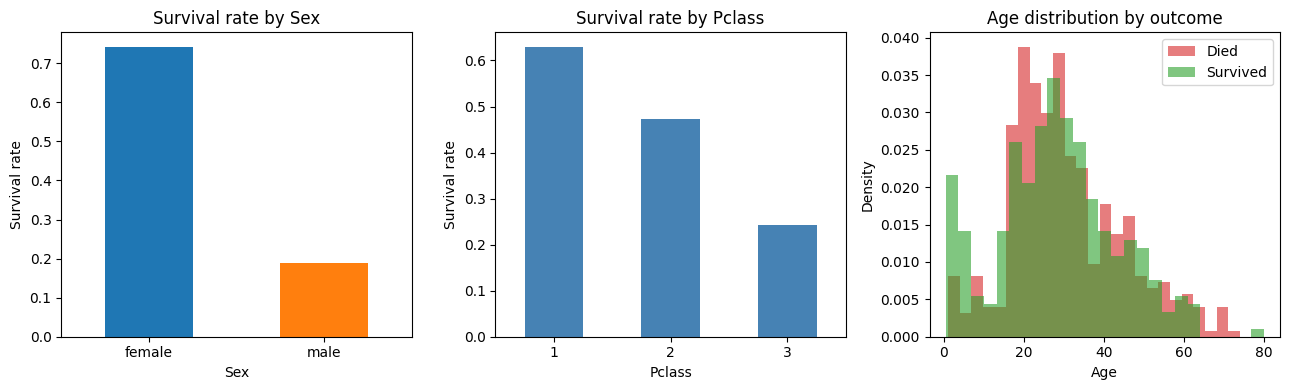

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

train_df.groupby('Sex')['Survived'].mean().plot.bar(
    ax=axes[0], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Survival rate by Sex')
axes[0].set_ylabel('Survival rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

train_df.groupby('Pclass')['Survived'].mean().plot.bar(
    ax=axes[1], color='steelblue')
axes[1].set_title('Survival rate by Pclass')
axes[1].set_ylabel('Survival rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

for sur, label, color in [(0, 'Died', '#d62728'), (1, 'Survived', '#2ca02c')]:
    axes[2].hist(train_df[train_df['Survived'] == sur]['Age'].dropna(),
                 bins=25, alpha=0.6, color=color, label=label, density=True)
axes[2].set_title('Age distribution by outcome')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
plt.show()


In [8]:
from skrub import TableVectorizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier

model = Pipeline([
    ('vectorizer', TableVectorizer()),
    ('clf',        HistGradientBoostingClassifier(random_state=0)),
])
model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,cardinality_threshold,40
,low_cardinality,OneHotEncoder..._output=False)
,high_cardinality,StringEncoder()
,numeric,PassThrough()
,datetime,DatetimeEncoder()
,specific_transformers,()
,drop_null_fraction,1.0


In [9]:
TARGET    = 'Survived'
DROP_COLS = ['PassengerId', 'Name', 'Ticket']   # identifiers, not predictors

X        = train_df.drop(columns=[TARGET] + DROP_COLS)
y        = train_df[TARGET]
X_kaggle = test_df.drop(columns=DROP_COLS)

**How `skrub` handles each predictor:**

Rather than manually engineering features, `skrub`'s `TableVectorizer` inspects each column's dtype and cardinality and assigns an encoder automatically:

| Column | Type | Encoder chosen by skrub |
|---|---|---|
| `Pclass` | low-cardinality int | `OneHotEncoder` |
| `Sex` | low-cardinality string | `OneHotEncoder` |
| `Age`, `Fare` | numeric, missing values | median imputation + `StandardScaler` |
| `SibSp`, `Parch` | numeric | `StandardScaler` |
| `Cabin` | high-cardinality string, 77% missing | `GapEncoder` (soft n-gram embedding) |
| `Embarked` | low-cardinality string | `OneHotEncoder` |

The key advantage over a manual `ColumnTransformer` is the **`GapEncoder`** for `Cabin`: instead of discarding it (due to missingness) or collapsing it to a binary flag, `GapEncoder` learns a low-dimensional continuous embedding from the raw string, recovering deck-level information automatically.

The base estimator is `HistGradientBoostingClassifier`, which natively handles missing values and does not require imputation for tree splits.

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print(f"CV accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")
print(f"Per-fold:    {scores.round(4)}")


CV accuracy: 0.8305 +/- 0.0282
Per-fold:    [0.8603 0.8596 0.8034 0.7921 0.8371]


In [11]:
model.fit(X, y)
y_pred = model.predict(X_kaggle)

submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived'   : y_pred
})
submission.to_csv('submission.csv', index=False)
display(submission.head())


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0


**Classifier used: `HistGradientBoostingClassifier` wrapped in a `skrub` + `sklearn` pipeline.**

**Why this classifier?**

The Titanic dataset presents two challenges that rule out simpler classifiers:

- **Mixed feature types and non-linear interactions.** Survival depended jointly on sex, class, and age in highly non-linear ways (e.g. women in 1st class survived at ~97%, men in 3rd class at ~13%). Gradient boosted trees capture such interactions naturally through successive decision splits, without requiring manual feature crosses.

- **Missing values.** `Age` is missing for 20% of passengers and `Cabin` for 77%. `HistGradientBoostingClassifier` handles missing values natively at split time — no imputation needed — which avoids introducing bias through imputed values.

LDA and logistic regression were not appropriate here: they both produce linear decision boundaries and assume no interactions between features, which is a poor fit for this dataset.

**Why a stratified 5-fold cross-validator?**

The passengers are IID observations with no temporal ordering or group structure, so standard $k$-fold CV is appropriate. Stratification ensures each fold preserves the overall survival rate (~38%), giving stable and unbiased accuracy estimates across folds.

**Kaggle public leaderboard score: `0.77033` (8,901stof leaderboard)**